In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the file we already saved
final_df = pd.read_csv("NYC_HVFHV_Master_Analysis_2025.csv")

# Now you can start charting!
print("Data loaded. You are ready to make charts.")

Data loaded. You are ready to make charts.


In [7]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, accuracy_score
import sklearn.preprocessing

c:\Users\preks\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [15:46:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Objective A Accuracy: 0.56


C:\Users\preks\AppData\Local\Temp\ipykernel_8644\3541319501.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=final_df['zone_grade'], palette='viridis')


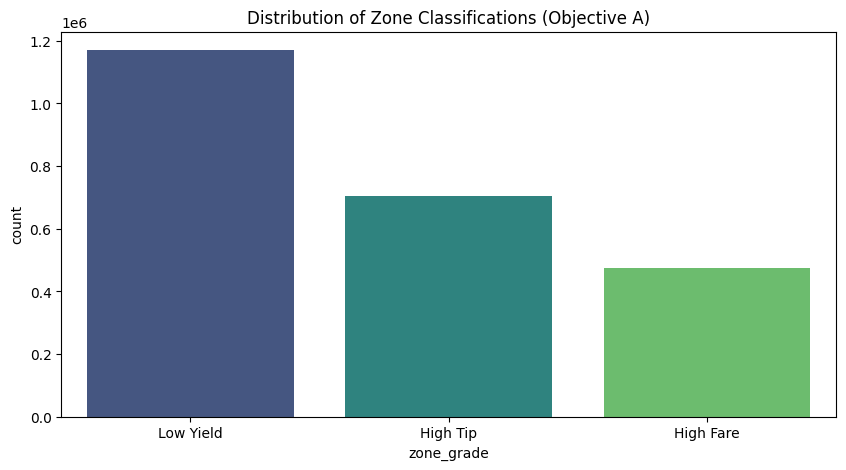

In [ ]:
# --- OBJECTIVE A: PREDICTING 'HIGH-VALUE' ZONES (CLASSIFICATION) ---
# Business Problem: Drivers need to know where to go to maximize earnings.
# Goal: Categorize zone-hour blocks into 'High Tip', 'High Fare', or 'Low Yield'.

# 1. Define thresholds for "High Value" using the 70th percentile of your dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


fare_threshold = final_df['base_passenger_fare'].quantile(0.7)
tip_threshold = final_df['tips'].quantile(0.7)

def categorize_zone(row):
    if row['tips'] > tip_threshold:
        return 'High Tip'
    elif row['base_passenger_fare'] > fare_threshold:
        return 'High Fare'
    else:
        return 'Low Yield'

# Apply the categorization logic to every row in the Master DataFrame
final_df['zone_grade'] = final_df.apply(categorize_zone, axis=1)

# 2. Convert text labels (High Tip, etc.) into numbers for XGBoost
le = LabelEncoder()
final_df['target_grade'] = le.fit_transform(final_df['zone_grade'])

# 3. Features: What the model uses to make the prediction
features_a = ['PULocationID', 'hour', 'day_of_week']
X_a = final_df[features_a]
y_a = final_df['target_grade']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(X_a, y_a, test_size=0.2, random_state=42)

# 4. Train XGBoost Classifier
clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', n_estimators=100)
clf.fit(X_train_a, y_train_a)

print(f"Objective A Accuracy: {accuracy_score(y_test_a, clf.predict(X_test_a)):.2f}")



C:\Users\preks\AppData\Local\Temp\ipykernel_8644\2416882488.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_a = sns.countplot(x=final_df['zone_grade'], palette='viridis', order=['High Tip', 'High Fare', 'Low Yield'])


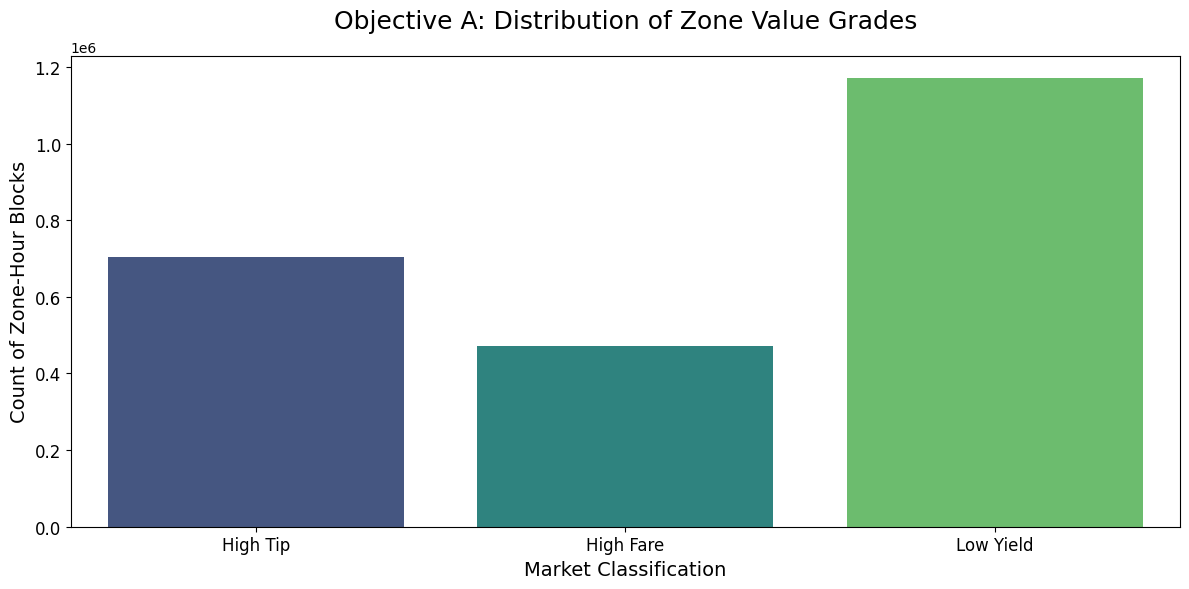

In [9]:
# Visual A: Predicted Distribution of Zone Grades
plt.figure(figsize=(12, 6))
ax_a = sns.countplot(x=final_df['zone_grade'], palette='viridis', order=['High Tip', 'High Fare', 'Low Yield'])
plt.title('Objective A: Distribution of Zone Value Grades', fontsize=18, pad=20)
plt.xlabel('Market Classification', fontsize=14)
plt.ylabel('Count of Zone-Hour Blocks', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

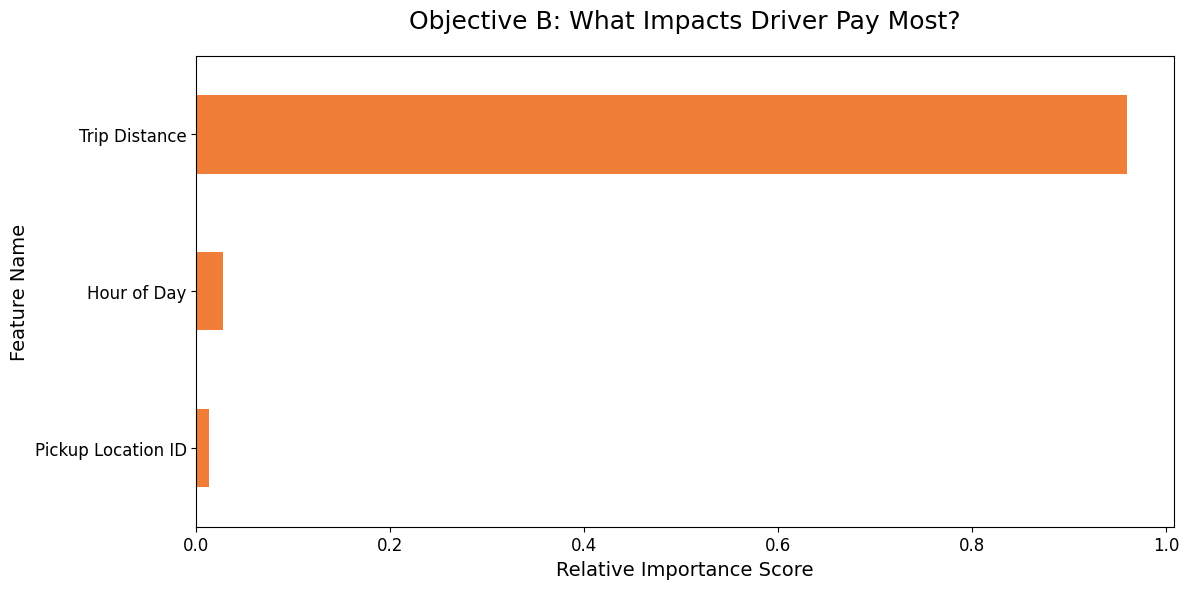

In [10]:
# --- OBJECTIVE B: ESTIMATING TAKE-HOME PAY (REGRESSION) ---
features_b = ['trip_miles', 'hour', 'PULocationID'] 
X_b = final_df[features_b]
y_b = final_df['driver_pay']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(X_b, y_b, test_size=0.2, random_state=42)

reg_pay = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100)
reg_pay.fit(X_train_b, y_train_b)

# Visual B: Feature Importance (Clearer labels)
plt.figure(figsize=(12, 6))
importance_b = pd.Series(reg_pay.feature_importances_, index=['Trip Distance', 'Hour of Day', 'Pickup Location ID'])
importance_b.sort_values().plot(kind='barh', color='#f07d38')
plt.title('Objective B: What Impacts Driver Pay Most?', fontsize=18, pad=20)
plt.xlabel('Relative Importance Score', fontsize=14)
plt.ylabel('Feature Name', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


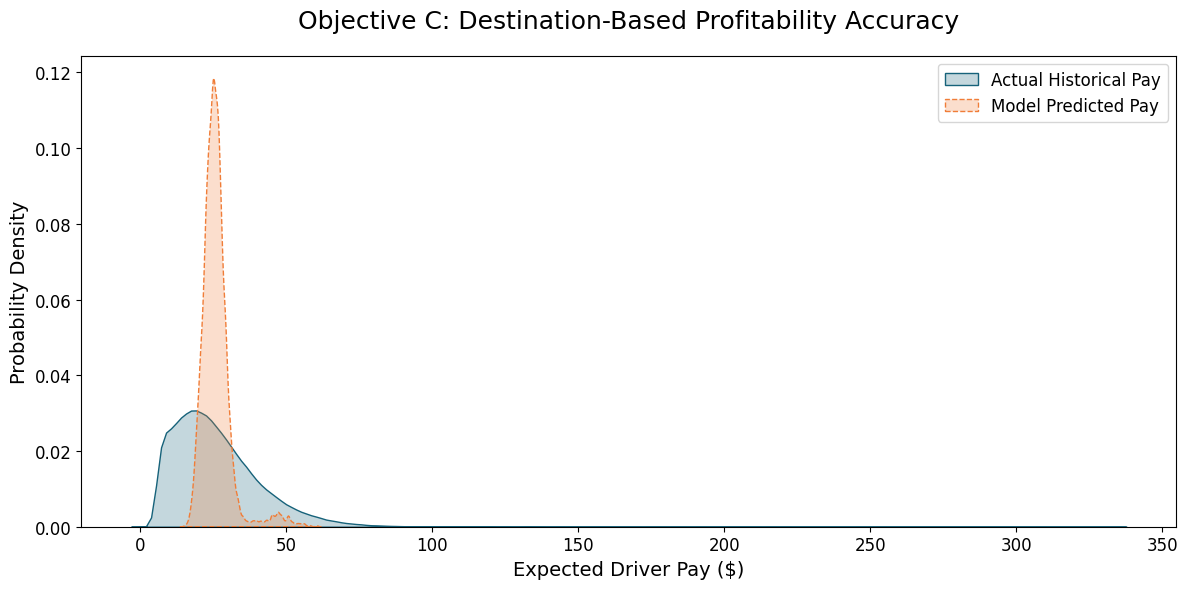

In [11]:
# --- OBJECTIVE C: DYNAMIC REVENUE HEAT MAP (NEXT-TRIP PROFITABILITY) ---
features_c = ['DOLocationID', 'hour', 'day_of_week']
X_c = final_df[features_c]
y_c = final_df['driver_pay'] 

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_c, y_c, test_size=0.2, random_state=42)

reg_heat = xgb.XGBRegressor(n_estimators=100)
reg_heat.fit(X_train_c, y_train_c)

# Visual C: Actual vs Predicted Pay (Improved Legend and Labels)
plt.figure(figsize=(12, 6))
y_pred_c = reg_heat.predict(X_test_c)
sns.kdeplot(y_test_c, label='Actual Historical Pay', fill=True, color='#16627a')
sns.kdeplot(y_pred_c, label='Model Predicted Pay', fill=True, color='#f07d38', linestyle='--')
plt.title('Objective C: Destination-Based Profitability Accuracy', fontsize=18, pad=20)
plt.xlabel('Expected Driver Pay ($)', fontsize=14)
plt.ylabel('Probability Density', fontsize=14)
plt.legend(fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

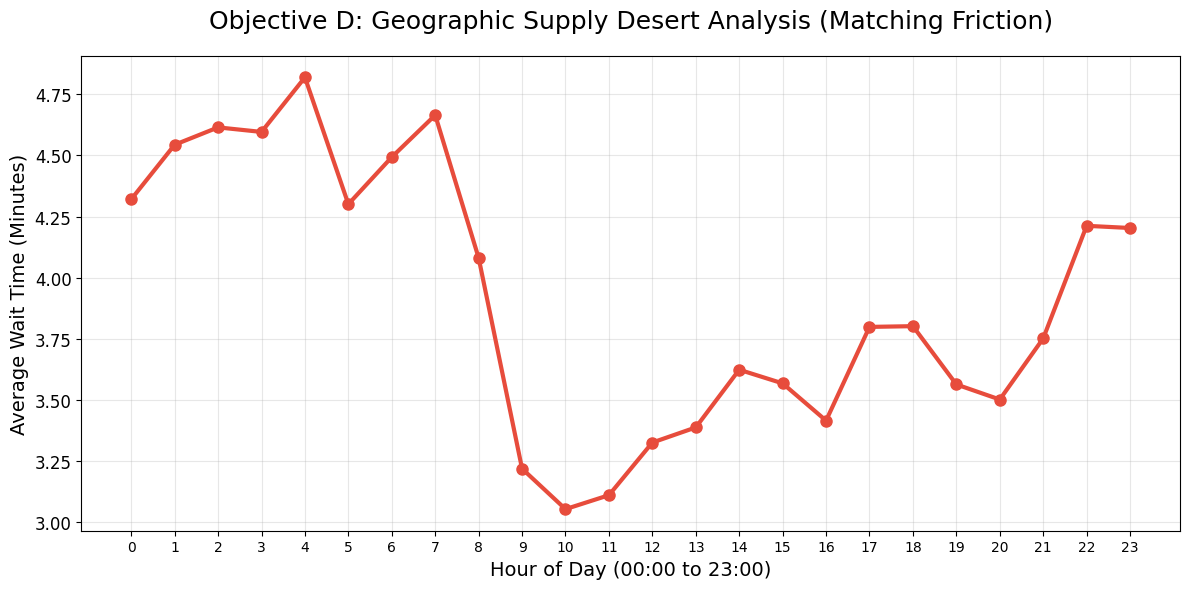

In [12]:
# --- OBJECTIVE D: PREDICTING MATCHING FRICTION (WAIT TIMES) ---
features_d = ['PULocationID', 'hour', 'day_of_week']
X_d = final_df[features_d]
y_d = final_df['wait_time'] 

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_d, y_d, test_size=0.2, random_state=42)

reg_wait = xgb.XGBRegressor(n_estimators=100)
reg_wait.fit(X_train_d, y_train_d)

# Visual D: Wait Times by Hour (Readable X-axis)
wait_by_hour = final_df.groupby('hour')['wait_time'].mean()
plt.figure(figsize=(12, 6))
plt.plot(wait_by_hour.index, wait_by_hour.values, marker='o', color='#e74c3c', linewidth=3, markersize=8)
plt.title('Objective D: Geographic Supply Desert Analysis (Matching Friction)', fontsize=18, pad=20)
plt.xlabel('Hour of Day (00:00 to 23:00)', fontsize=14)
plt.ylabel('Average Wait Time (Minutes)', fontsize=14)
plt.xticks(range(0, 24), fontsize=10)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()